# MatrixDesing

В этом ноутбуке я построю матрицу взаимодействия и протестирую AILS модель.

## Импорт библиоткек

In [18]:
import pandas as pd
import numpy as np
import implicit
import os
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  
import matplotlib.pyplot as plt
from pathlib import Path

## Загрузка данных

In [19]:
BASE_PATH = os.path.abspath("../../../Tables/CleanTable")

In [20]:
users_clean = pd.read_csv(os.path.join(BASE_PATH, 'users_clean.csv'), encoding='utf-8')
items_dim = pd.read_csv(os.path.join(BASE_PATH, 'items_dim.csv'), encoding='utf-8')
user_items = pd.read_csv(os.path.join(BASE_PATH, 'user_item_clean.csv'), encoding='utf-8')

In [21]:
users_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2711 entries, 0 to 2710
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_user          2711 non-null   int64  
 1   Имя              2711 non-null   str    
 2   Телефон          2711 non-null   str    
 3   Категории        2711 non-null   str    
 4   Оплачено в руб   2711 non-null   float64
 5   Последний визит  2711 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 127.2 KB


In [22]:
items_dim.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   id_item                                235 non-null    int64
 1   Название услуги или товара             235 non-null    str  
 2   Категория товара или услуги в продаже  235 non-null    str  
dtypes: int64(1), str(2)
memory usage: 5.6 KB


In [23]:
user_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 6679 entries, 0 to 6678
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Имя мастера            6679 non-null   str    
 1   Специализация мастера  6679 non-null   str    
 2   Имя клиента            6679 non-null   str    
 3   Время визита           6679 non-null   str    
 4   Категория услуги       6679 non-null   str    
 5   Название услуги        6679 non-null   str    
 6   Стоимость, руб         6679 non-null   float64
 7   Категория              6679 non-null   str    
 8   id_user                6679 non-null   int64  
 9   id_item                6679 non-null   int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 521.9 KB


## Разбиение df на train/val/test (Time-based split)

Для актуальности данных буду использовать Time-based split в таком формате:
- 75 дней (с 5 декабря по 18 февраля) на train
- 7 дней (с 19 февраля по 25 февраля) на val 
- 7 дней (с 26 февраля по 4 марта) на test


Приведем столбец "Время визита" к datetime64

In [24]:
user_items.dtypes

Имя мастера                  str
Специализация мастера        str
Имя клиента                  str
Время визита                 str
Категория услуги             str
Название услуги              str
Стоимость, руб           float64
Категория                    str
id_user                    int64
id_item                    int64
dtype: object

In [25]:
user_items['Время визита'] = pd.to_datetime(user_items['Время визита'], errors='coerce')
user_items['Время визита'].dtypes

dtype('<M8[us]')

Сортируем по дате

In [26]:
user_items = user_items.sort_values(by='Время визита', ascending=False)

In [27]:
f"Количество уникальных дат визитов: {user_items['Время визита'].dt.date.nunique()}"

'Количество уникальных дат визитов: 89'

### Разбиваем user_items на 3 DataFrame по времени визита

In [28]:
val_start = pd.Timestamp('2026-02-19')
test_start = pd.Timestamp('2026-02-26')

In [29]:
train_df = user_items[user_items['Время визита'] < val_start].copy()
val_df = user_items[(user_items['Время визита'] >= val_start) & (user_items['Время визита'] < test_start)].copy()
test_df = user_items[user_items['Время визита'] >= test_start].copy()

In [30]:
train_df.shape, val_df.shape, test_df.shape

((5531, 10), (605, 10), (543, 10))

Теперь важно оставить в val и test только тех, кто был в train, чтобы IALS не выдал ошибку 

In [31]:
known_users = set(train_df['id_user'].unique())
known_items = set(train_df['id_item'].unique())

In [32]:
val_df = val_df[val_df['id_user'].isin(known_users) & val_df['id_item'].isin(known_items)]
test_df = test_df[test_df['id_user'].isin(known_users) & test_df['id_item'].isin(known_items)]

In [33]:
train_df.shape, val_df.shape, test_df.shape

((5531, 10), (506, 10), (419, 10))

## Построение матрицы __User-Item__

Формула для Confidence (weight)

__Weight = 1 + log(N)__, где N - количество посещений

Такая формула была выбрана, потому что она:
1)  Учитывает размерность самых частых услуг (log сгладит услуги с крупными посещениями).
2) Учитывает частоту посещений и поощеряет услугу, если клиент часто на неё ходит.

Тогда матрица будет в формате:

`id_user` | `id_item` | `Weight`

#### Считаем Weight

In [34]:
train_matrix = train_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
test_matrix = test_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
val_matrix = val_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')

In [35]:
print('train_matrix:', train_matrix.head(3), '\n',
       'test_matrix:', test_matrix.head(3), '\n',
         'val_matrix:', val_matrix.head(3), sep='\n')

train_matrix:
   id_user  id_item  N_visits
0        7        0         1
1        7        9         2
2        7       10         2


test_matrix:
   id_user  id_item  N_visits
0       77      104         1
1       77      192         1
2       79        8         1


val_matrix:
   id_user  id_item  N_visits
0        9        0         1
1        9      130         1
2        9      194         1


In [36]:
train_matrix['confidence'] = 1 + np.log(train_matrix['N_visits'])
test_matrix['confidence'] = 1 + np.log(test_matrix['N_visits'])
val_matrix['confidence'] = 1 + np.log(val_matrix['N_visits'])

In [37]:
print('train_matrix:', train_matrix.head(3), '\n',
       'test_matrix:', test_matrix.head(3), '\n',
         'val_matrix:', val_matrix.head(3), sep='\n')

train_matrix:
   id_user  id_item  N_visits  confidence
0        7        0         1    1.000000
1        7        9         2    1.693147
2        7       10         2    1.693147


test_matrix:
   id_user  id_item  N_visits  confidence
0       77      104         1         1.0
1       77      192         1         1.0
2       79        8         1         1.0


val_matrix:
   id_user  id_item  N_visits  confidence
0        9        0         1         1.0
1        9      130         1         1.0
2        9      194         1         1.0


In [38]:
''' 
# 1. Считаем посещения с весами
user_item_matrix = user_items.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
print(user_item_matrix, end='\n'*5)
# 2. Weight = 1 + log(N)
user_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])
print(user_item_matrix)'''

" \n# 1. Считаем посещения с весами\nuser_item_matrix = user_items.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')\nprint(user_item_matrix, end='\n'*5)\n# 2. Weight = 1 + log(N)\nuser_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])\nprint(user_item_matrix)"

#### CSR матрица

Требуедтся переопределить id, из-за того что в них есть пропуски и матрица из-за слишком разряженная

In [39]:
class IDMapper:
    def __init__(self, ids):
        self.unique_ids = sorted(set(ids))
        self.id_to_idx = {id_: i for i, id_ in enumerate(self.unique_ids)}
        self.idx_to_id = {i: id_ for i, id_ in enumerate(self.unique_ids)}

    def to_idx(self, ids):
        return ids.map(self.id_to_idx)

    @property
    def size(self):
        return len(self.unique_ids)

In [40]:
user_mapper = IDMapper(user_items['id_user'])
item_mapper = IDMapper(user_items['id_item'])

In [41]:
rows_train = user_mapper.to_idx(train_matrix['id_user'])
cols_train = item_mapper.to_idx(train_matrix['id_item'])
data_train = train_matrix['confidence']

rows_test = user_mapper.to_idx(test_matrix['id_user'])
cols_test = item_mapper.to_idx(test_matrix['id_item'])
data_test = test_matrix['confidence']

rows_val = user_mapper.to_idx(val_matrix['id_user'])
cols_val = item_mapper.to_idx(val_matrix['id_item'])
data_val = val_matrix['confidence']

In [42]:
train_sparse = sparse.csr_matrix((data_train, (rows_train, cols_train)),
                                  shape=(user_mapper.size, item_mapper.size))

In [43]:
test_sparse = sparse.csr_matrix((data_test, (rows_test, cols_test)),
                                  shape=(user_mapper.size, item_mapper.size))

In [44]:
val_sparse = sparse.csr_matrix((data_val, (rows_val, cols_val)),
                                  shape=(user_mapper.size, item_mapper.size))

In [45]:
train_sparse.shape, test_sparse.shape, val_sparse.shape

((1265, 161), (1265, 161), (1265, 161))

#### Оценка матрицы

In [46]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('train_sparse:')
weights = train_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
train_sparse:
N=1 → вес≥1.00: 3836 (100.0%)
N=2 → вес≥1.69: 1157 (30.2%)
N=3 → вес≥2.10: 365 (9.5%)
N=4 → вес≥2.39: 110 (2.9%)
N=5 → вес≥2.61: 39 (1.0%)
N=6 → вес≥2.79: 15 (0.4%)
N=7 → вес≥2.95: 6 (0.2%)
N=8 → вес≥3.08: 3 (0.1%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


In [47]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('test_sparse:')
weights = test_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
test_sparse:
N=1 → вес≥1.00: 404 (100.0%)
N=2 → вес≥1.69: 15 (3.7%)
N=3 → вес≥2.10: 0 (0.0%)
N=4 → вес≥2.39: 0 (0.0%)
N=5 → вес≥2.61: 0 (0.0%)
N=6 → вес≥2.79: 0 (0.0%)
N=7 → вес≥2.95: 0 (0.0%)
N=8 → вес≥3.08: 0 (0.0%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


In [48]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('val_sparse:')
weights = val_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
val_sparse:
N=1 → вес≥1.00: 494 (100.0%)
N=2 → вес≥1.69: 12 (2.4%)
N=3 → вес≥2.10: 0 (0.0%)
N=4 → вес≥2.39: 0 (0.0%)
N=5 → вес≥2.61: 0 (0.0%)
N=6 → вес≥2.79: 0 (0.0%)
N=7 → вес≥2.95: 0 (0.0%)
N=8 → вес≥3.08: 0 (0.0%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


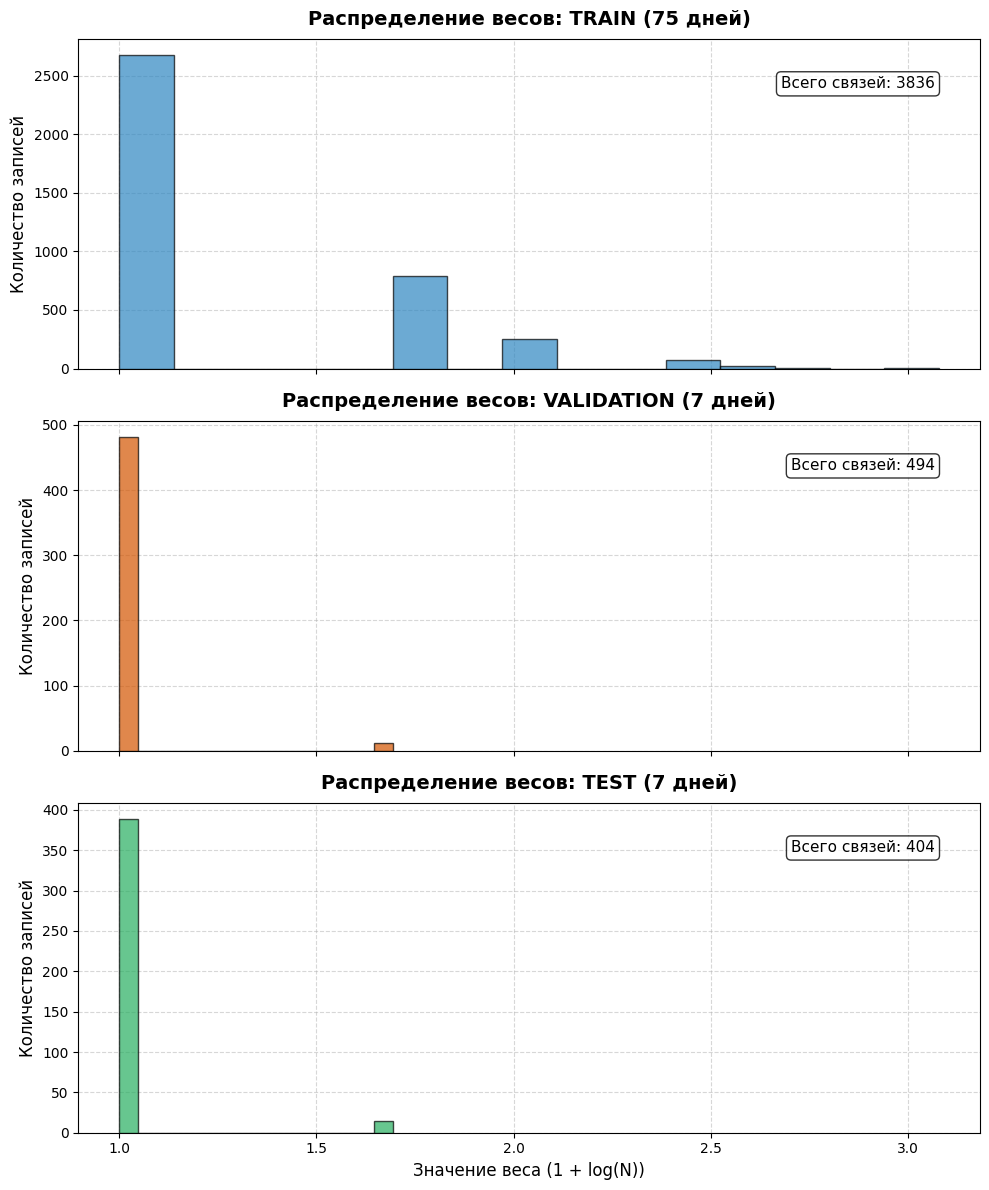

In [49]:
weights_list = [train_sparse.data, val_sparse.data, test_sparse.data]
titles = ['Распределение весов: TRAIN (75 дней)', 
          'Распределение весов: VALIDATION (7 дней)', 
          'Распределение весов: TEST (7 дней)']
colors = ['#2E86C1', '#D35400', '#27AE60']

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i, ax in enumerate(axes):
    # Рисуем гистограмму
    n, bins, patches = ax.hist(weights_list[i], bins=15, color=colors[i], 
                               alpha=0.7, edgecolor='black', zorder=3)
    
    # Настройка заголовков и осей
    ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Количество записей', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
    # Добавляем аннотацию с общим количеством связей
    ax.annotate(f'Всего связей: {len(weights_list[i])}', 
                xy=(0.95, 0.85), xycoords='axes fraction',
                fontsize=11, ha='right', bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Общая подпись для оси X
plt.xlabel('Значение веса (1 + log(N))', fontsize=12)

# Автоматическое выравнивание, чтобы заголовки не налезали на графики
plt.tight_layout()
plt.show()

In [50]:
print("=== БАЗОВАЯ ИНФОРМАЦИЯ ===")
print(f"Форма матрицы: {train_sparse.shape}")
print(f"NNZ (непустых): {train_sparse.nnz}")
print(f"Доля заполненности: {train_sparse.nnz / (train_sparse.shape[0] * train_sparse.shape[1]):.4f}")
print(f"Диапазон весов: {train_sparse.data.min():.2f} → {train_sparse.data.max():.2f}")
print(f"Средний вес: {train_sparse.data.mean():.2f}")

=== БАЗОВАЯ ИНФОРМАЦИЯ ===
Форма матрицы: (1265, 161)
NNZ (непустых): 3836
Доля заполненности: 0.0188
Диапазон весов: 1.00 → 3.08
Средний вес: 1.26


In [52]:
print(train_matrix.nlargest(5, 'confidence'))

      id_user  id_item  N_visits  confidence
944       694        9         8    3.079442
945       694       10         8    3.079442
1899     1313      101         8    3.079442
476       328      105         7    2.945910
3111     2261      104         7    2.945910


#### Сохранение матрицы

In [57]:
result_path = Path('../../../results/matrices')


In [59]:
sparse.save_npz(result_path / 'artnail_user_item_sparse_train.npz', train_sparse)
sparse.save_npz(result_path / 'artnail_user_item_sparse_val.npz', val_sparse)
sparse.save_npz(result_path / 'artnail_user_item_sparse_test.npz', test_sparse)
print(f"  Путь: {result_path / 'artnail_user_item_sparse_train.npz'}")
print(f"  Размер: {os.path.getsize(result_path / 'artnail_user_item_sparse_train.npz') / 1024:.1f} КБ")

  Путь: ..\..\..\results\matrices\artnail_user_item_sparse_train.npz
  Размер: 7.6 КБ
